# Two α per redshift: a wiggle/no-wiggle model-independent parametrization

DESI DR1 full shape + post-reconstruction BAO, the same data, EFT model and priors as the lean pipeline
(`model.py`, `analysis.ipynb`). Only the parametrization of the cosmology-dependent block changes.

**The proposal.** Split the fiducial linear spectrum at $z_N=1.491$ into a smooth part and wiggles,
$T(k)=T_{\rm nw}(k)\,[1+O(k)]$. Model the broadband with a spline on a few nodes and keep the wiggles as
the fiducial template, rescaled by the sound horizon:

$$P_{\rm lin}(k,z_N)=a(k)\,T_{\rm nw}(k)\,\big[1+O(k\,\alpha_{r_s})\big],\qquad \alpha_{r_s}=\frac{h\,r_d}{(h\,r_d)_{\rm fid}} .$$

Each redshift gets two AP dilations $\alpha_\parallel(z),\alpha_\perp(z)$ that apply to the whole full shape,
and the post-reconstruction BAO is *predicted*: $\alpha^{\rm BAO}=\alpha/\alpha_{r_s}$. That replaces
the baseline's $H, D_A$ per redshift + $h_{\rm conv}$ + ten free BAO dilations, and its 60 nodes by 16.
This is **model A** (`wiggle_model.py`, `rs_free=True`).

**A near-symmetry.** With the broadband free, scaling $\alpha_{r_s}$ and every $\alpha$ by the same
$\lambda$ and dilating $a(k)$ leaves the observed multipoles unchanged. The wiggles see
$\alpha/\alpha_{r_s}$, which is unchanged. The broadband dilates, and the spline absorbs that. The AP volume
factor $1/(q_\parallel q_\perp^2)$ cancels the $\lambda^3$. So $\alpha_{r_s}$ is fixed by its prior unless
the node basis is too coarse to follow a dilation of $T_{\rm nw}$. **Model B** removes the direction by
setting $\alpha_{r_s}=1$. Its two α per redshift *are* the BAO α's, its template is the spectrum in
sound-horizon units, $P(k\,r_d)/r_d^3$, and it needs no split.

**The test** is the one of meeting item B. Each MI chain is projected onto a cosmological model,
$p(\theta|d)\propto p_{\rm MI}(\phi(\theta)|d)/\pi_{\rm MI}(\phi(\theta))\,\pi(\theta)$, and compared with
the *exact* direct chain of that model: CosmoPower/ede-v2 spectra, not the wiggle model. The models are
ΛCDM (lcdm3), ΛCDM with ω_b (BBN) and n_s free (lcdm5), w0waCDM (w0wa7) and EDE (ede7). A miss splits into
*representation*, where the direct chain is reweighted by $L_{\rm wiggle}/L_{\rm exact}$, and *compression*.

Scripts: `wiggle_model.py`, `wiggle_settings.py`, `wiggle_gates.py`, `wiggle_sample.py`, `wiggle_recovery.py`
(launcher `exec_wiggle.sbatch`). This notebook is built from `wiggle_analysis.py` by `build_wiggle_nb.py`
and executed by `exec_wiggle_nb.sbatch`. It only reads their outputs, plus light evaluations of the model.

In [1]:
import os, sys, re, glob
import numpy as np
import matplotlib, matplotlib.ticker
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
sys.path.insert(0, os.path.abspath('.'))
import settings as S
import wiggle_settings as W
from model import COSMO_MODELS, COSMO_TEX, COSMO_BOX, EDE_BOX
from sampling import log, chain_diagnostics
from getdist import MCSamples, plots

RUNS = [w for w in ('A', 'B', 'Be2', 'Be245', 'Ae245', 'Ag245') if os.path.exists(os.path.join(S.OUT_ROOT, f'wiggle_{w}', 'chain_mi.npz'))]
REC_RUNS = [w for w in RUNS if w not in ('Ae245', 'Ag245')] + [w for w in ('Be2F', 'Be245F', 'Ae245F', 'Ag245F') if os.path.exists(os.path.join(S.OUT_ROOT, f'wiggle_{w}', 'recovery_gauss.npz'))]
OUT = {w: os.path.join(S.OUT_ROOT, f'wiggle_{w}') for w in dict.fromkeys(RUNS + REC_RUNS)}       # Be2F: Be2's chain, data-weighted direct map
GATES = os.path.join(S.OUT_ROOT, 'wiggle_gates', 'gates.npz')
FIG = os.path.join(S.OUT_ROOT, 'wiggle_figs'); os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.dpi': 110})
C_D, C_OLD = '#D84315', '#757575'                                       # direct, baseline 106-parameter MI
COL = {'A': '#E8710A', 'B': '#1E88E5', 'Be2': '#2E7D32', 'Be2F': '#9CCC65', 'Be245': '#6A1B9A', 'Be245F': '#BA68C8', 'Ae245': '#00838F', 'Ae245F': '#00ACC1', 'Ag245': '#AD1457', 'Ag245F': '#F06292'}; C_A, C_B = COL['A'], COL['B']
def savefig(name):
    plt.savefig(os.path.join(FIG, f'{name}.pdf'), bbox_inches='tight'); plt.savefig(os.path.join(FIG, f'{name}.png'), dpi=140, bbox_inches='tight')
    plt.show()
G = dict(np.load(GATES)); ENV = dict(np.load(os.path.join(S.OUT_ROOT, 'wiggle_gates', 'envelope.npz')))
MW = {w: W.build(W.resolve(w), verbose=False)[0] for w in dict.fromkeys(['A', 'B'] + RUNS)}
MA, MB = MW['A'], MW['B']
s0 = S.resolve('baseline'); M0, _ = S.build(s0, verbose=False)
log("parameters: " + ", ".join(f"model {w} {M.n_mi}" for w, M in MW.items()) + f", baseline {M0.n_mi}; MI chains found for {RUNS}")

jax: on


[   23.1s] parameters: model A 52, model B 51, model Be2 53, model Be245 58, model Ae245 59, model Ag245 59, baseline 106; MI chains found for ['A', 'B', 'Be2', 'Be245', 'Ae245', 'Ag245']


## 1. The split

$T_{\rm nw}$ is the Eisenstein–Hu no-wiggle shape times the ratio $T/T_{\rm EH}$ smoothed by a Gaussian of
0.25 dex in $k$ (Vlah et al. 2016). Below $3\times10^{-3}\,{\rm Mpc}^{-1}$, $O$ is tapered to exactly zero, and
$T_{\rm nw}\equiv T/(1+O)$, so model A at $\alpha_{r_s}=1$ is exactly the template. The DST split that pybird
uses (Hamann et al. 2010) leaves a ~10% non-oscillatory residual near the turnover. Model A would rescale
that residual as if it were BAO, so it is shown only for comparison. Model B does not use the split.

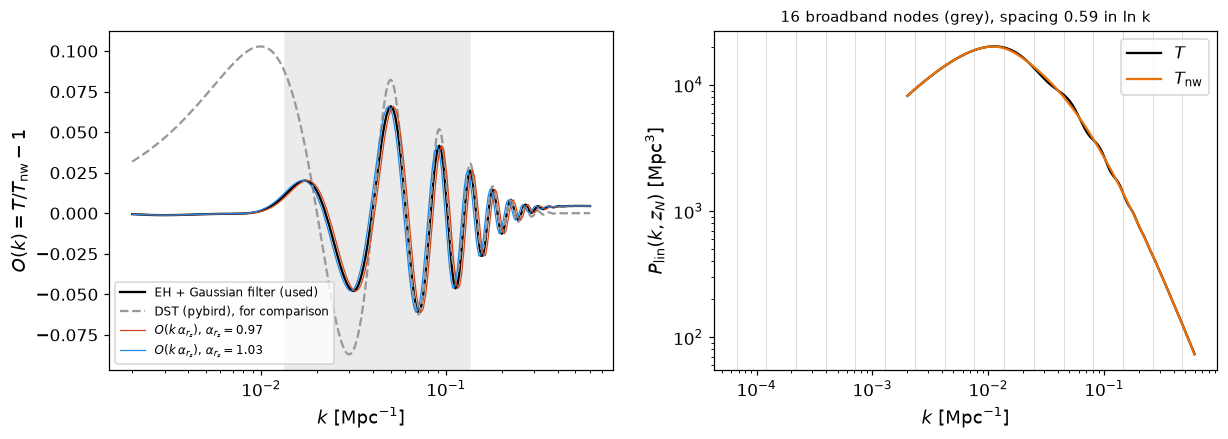

[   26.1s] max |O| = 0.066; data range shaded (0.02-0.2 h/Mpc at h_fid)


In [2]:
k = G['split_k']; m = (k > 2e-3) & (k < 0.6)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].semilogx(k[m], G['split_O'][m], color='k', label='EH + Gaussian filter (used)')
ax[0].semilogx(k[m], G['split_O_dst'][m], color='0.6', ls='--', label='DST (pybird), for comparison')
for lam, c in ((0.97, C_D), (1.03, C_B)):
    ax[0].semilogx(k[m], np.asarray(MA.O_of_k(jnp.array(k[m] * lam))), color=c, lw=0.8, label=rf'$O(k\,\alpha_{{r_s}})$, $\alpha_{{r_s}}={lam}$')
ax[0].axvspan(0.02 * MA.h_fid, 0.2 * MA.h_fid, color='0.92', zorder=0)
ax[0].set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$'); ax[0].set_ylabel(r'$O(k)=T/T_{\rm nw}-1$'); ax[0].legend(fontsize=8)
ax[1].loglog(k[m], G['split_P'][m], color='k', label=r'$T$'); ax[1].loglog(k[m], G['split_P'][m] / (1 + G['split_O'][m]), color=C_A, label=r'$T_{\rm nw}$')
for x in MA.nodes_mpc: ax[1].axvline(float(x), color='0.85', lw=0.6, zorder=0)
ax[1].set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$'); ax[1].set_ylabel(r'$P_{\rm lin}(k,z_N)\ [{\rm Mpc}^3]$'); ax[1].legend()
ax[1].set_title(f'{MA.n_amp} broadband nodes (grey), spacing {MA.node_spacing:.2f} in ln k', fontsize=10)
savefig('split'); plt.close('all')
log(f"max |O| = {np.abs(G['split_O']).max():.3f}; data range shaded (0.02-0.2 h/Mpc at h_fid)")

## 2. Gates, and whether $\alpha_{r_s}$ is a gauge

The log of `wiggle_gates.py` is printed below. W1: the MI likelihood at the fiducial against the exact direct one.
W2: the BAO α's that the MI parameters predict against the direct model's α's at direct-chain draws.
W3 moves model A along the near-symmetry and, for contrast, moves $\alpha_{r_s}$ alone and the α's alone. It
also gives the fraction of a broadband dilation $d\ln T_{\rm nw}/d\ln k$ that each node basis cannot hold.

In [3]:
glog = sorted(glob.glob(os.path.join(S.OUT_ROOT, 'logs', 'wiggle_*.log')), key=os.path.getmtime)
glog = [f for f in glog if 'W3 dilation' in open(f).read()][-1]
print(f"(from {glog})")
print(''.join(l for l in open(glog) if re.search(r'\] W[0-5]', l)))

(from /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/output/desi_fsbao/logs/wiggle_3567731.log)
[   24.4s] W0 split: max |O| = 0.0659 at k = 0.0502/Mpc; |O_raw| below the taper (k < 4e-3/Mpc) 1.21e-03; |O| above 0.5/Mpc 4.50e-03; CPJ modes [1.00e-05, 9.8]/Mpc
[   24.4s] W0 EH+filter vs DST (pybird): max |O| in 0.01-0.5/Mpc 0.0659 vs 0.1028; below 0.01/Mpc 1.60e-03 vs 1.03e-01
[   63.5s] W1 [A] fiducial: ln L wiggle -173.970226, exact -173.970177, diff -4.90e-05
[   79.3s] W1 [B] fiducial: ln L wiggle -173.970226, exact -173.970177, diff -4.90e-05
[   94.9s] W2 [A] lcdm5: BAO alphas predicted vs direct, max |rel diff| 4.8e-05; FS AP inputs vs the direct model's: H/H0 4.4e-16, D_A H0 4.4e-16
[  102.7s] W2 [B] lcdm5: BAO alphas predicted vs direct, max |rel diff| 4.8e-05; FS AP inputs vs the direct model's: H/H0 4.6e-02, D_A H0 4.4e-02  (B: both differ by alpha_rs by construction)
[  115.6s] W2 [A] w0wa7: BAO alphas predicted vs direct, max |rel diff| 2.8e-04; FS AP in

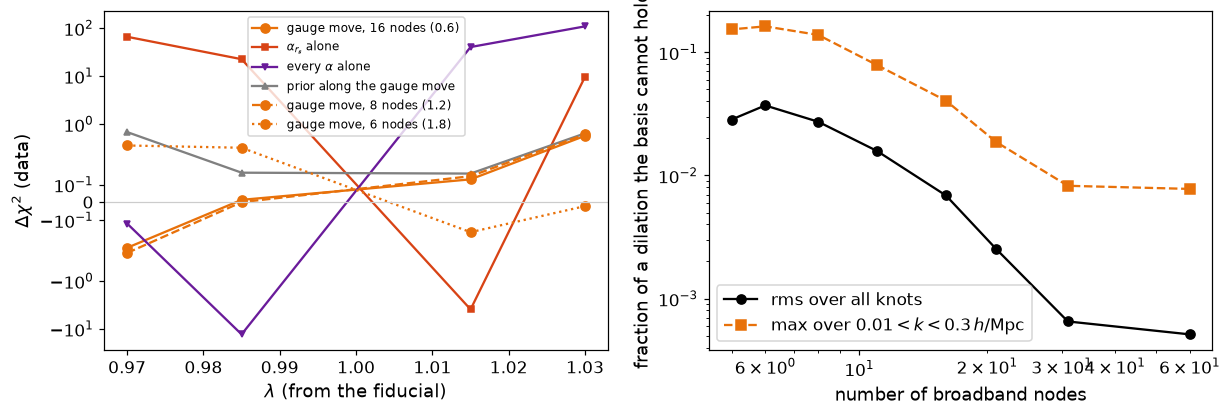

[   29.4s] A: at lambda = 1.03 the gauge move costs chi2 0.568 (prior 0.64); alpha_rs alone 9.7; alphas alone 108.3


[   29.4s] A120: at lambda = 1.03 the gauge move costs chi2 0.609 (prior 0.58); alpha_rs alone 9.7; alphas alone 108.3


[   29.4s] A180: at lambda = 1.03 the gauge move costs chi2 -0.021 (prior 0.57); alpha_rs alone 9.7; alphas alone 108.3


In [4]:
lams = G['W3_lams']
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for n, ls in (('A', '-'), ('A120', '--'), ('A180', ':')):
    g, rs, al, pg = G[f'W3_{n}']
    lab = {'A': '16 nodes (0.6)', 'A120': '8 nodes (1.2)', 'A180': '6 nodes (1.8)'}[n]
    ax[0].plot(lams, g, 'o' + ls, color=C_A, label=f'gauge move, {lab}')
    if n == 'A':
        ax[0].plot(lams, rs, 's-', color=C_D, ms=4, label=r'$\alpha_{r_s}$ alone')
        ax[0].plot(lams, al, 'v-', color='#6A1B9A', ms=4, label=r'every $\alpha$ alone')
        ax[0].plot(lams, pg, '^-', color='0.5', ms=4, label='prior along the gauge move')
ax[0].set_yscale('symlog', linthresh=0.3); ax[0].axhline(0, color='0.8', lw=0.8)
ax[0].set_xlabel(r'$\lambda$ (from the fiducial)'); ax[0].set_ylabel(r'$\Delta\chi^2$ (data)'); ax[0].legend(fontsize=8)
sp, fr = G['W3_spacings'], G['W3_dilation']
ax[1].loglog(fr[:, 0], fr[:, 1], 'o-', color='k', label='rms over all knots')
ax[1].loglog(fr[:, 0], fr[:, 2], 's--', color=C_A, label=r'max over $0.01<k<0.3\,h/$Mpc')
ax[1].set_xlabel('number of broadband nodes'); ax[1].set_ylabel('fraction of a dilation the basis cannot hold')
ax[1].legend(); savefig('gauge'); plt.close('all')
for n in ('A', 'A120', 'A180'):
    g, rs, al, pg = G[f'W3_{n}']
    log(f"{n}: at lambda = 1.03 the gauge move costs chi2 {g[-1]:.3f} (prior {pg[-1]:.2f}); alpha_rs alone {rs[-1]:.1f}; alphas alone {al[-1]:.1f}")

## 3. How few nodes, and what the wiggles need: representing real spectra

For each direct model, 300 draws of its exact chain are mapped into the wiggle model: weighted least squares of
$\ln a$ (and, with an envelope, of the $e_j$) on the 80 emulator knots, then the α's, $f$ and $D$ ratios.
W5 is the leftover in $\ln P$ inside $0.01<k<0.3\,h/$Mpc. W4 is what the leftover does to the likelihood: the
spread of $\Delta\ln L=\ln L_{\rm wiggle}-\ln L_{\rm exact}$ over the posterior, and the posterior shift implied by
importance weights. That shift is reliable only when ESS/N is not small.

**Without an envelope** (models A, B) the leftover is about 0.4% rms in ln P. It hardly changes between 31 and 6
nodes, and drops only at 60 nodes, where the spline can move the wiggles. So it is the BAO wiggles themselves:
their amplitude and damping follow $\omega_b/\omega_m$ and the Silk scale, which a template rescaled only by
$\alpha_{r_s}$ cannot do. **With an envelope**, $[1+(1+e_0+e_1x+\dots)\,O(k\alpha_{r_s})]$ with $x=\ln(k/0.1\,{\rm Mpc}^{-1})$,
the model carries the standard BAO-fit amplitude/damping freedom: one to three global parameters.

The first table compares with the existing direct likelihood, whose $r_d$ has the wrong $\omega_b$ dependence (section 6).
That is why lcdm5 and w0wa7 stay off by ~1.5σ in $\omega_b$ even with the envelope. The second table compares with the
corrected $r_d$. The draws of all tables are the same 300 per model, from the original chains.

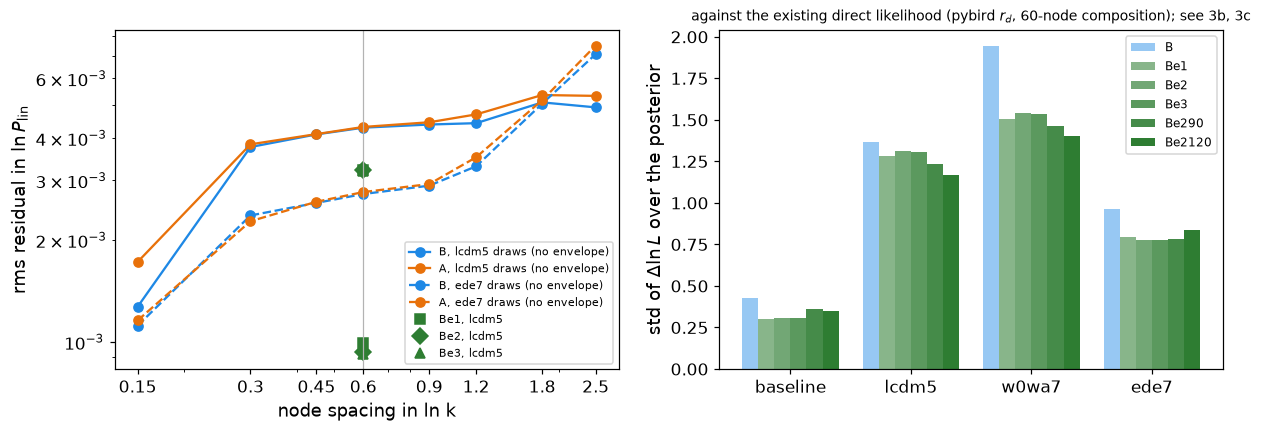

model                     baseline                      lcdm5                      w0wa7                       ede7
        std dlnL  ESS/N  max|shift| std dlnL  ESS/N  max|shift| std dlnL  ESS/N  max|shift| std dlnL  ESS/N  max|shift|
A            0.45   0.73     0.33σ      1.39   0.08     1.46σ      1.83   0.01     2.18σ      0.98   0.08     1.00σ
B30          0.36   0.85     0.26σ      0.64   0.57     0.34σ      1.28   0.09     1.04σ      0.92   0.10     0.96σ
B120         0.49   0.84     0.21σ      1.38   0.09     1.39σ      1.86   0.06     1.43σ      0.93   0.15     0.65σ
B            0.43   0.76     0.29σ      1.37   0.09     1.45σ      1.94   0.01     2.31σ      0.96   0.09     0.90σ
Be1          0.30   0.91     0.13σ      1.28   0.06     1.72σ      1.51   0.11     1.34σ      0.79   0.39     0.21σ
Be2          0.31   0.91     0.14σ      1.31   0.06     1.75σ      1.54   0.11     1.35σ      0.78   0.40     0.23σ
Be3          0.31   0.91     0.15σ      1.31   0.06     1.73σ      1

[   30.5s] Be1 w0wa7: envelope the direct spectra need: e = [-0.125] +- [0.08]


[   30.5s] Be1 ede7: envelope the direct spectra need: e = [-0.086] +- [0.06]


[   30.5s] Be2 lcdm5: envelope the direct spectra need: e = [-0.067 -0.019] +- [0.079 0.013]


[   30.5s] Be2 w0wa7: envelope the direct spectra need: e = [-0.134 -0.019] +- [0.082 0.011]


...

[   30.5s] Be290 w0wa7: envelope the direct spectra need: e = [-0.139 -0.04 ] +- [0.086 0.022]


[   30.5s] Be290 ede7: envelope the direct spectra need: e = [-0.081 -0.001] +- [0.066 0.017]


[   30.5s] Be2120 lcdm5: envelope the direct spectra need: e = [-0.058 -0.017] +- [0.079 0.012]


[   30.5s] Be2120 w0wa7: envelope the direct spectra need: e = [-0.128 -0.014] +- [0.084 0.01 ]


[   30.5s] Be2120 ede7: envelope the direct spectra need: e = [-0.077  0.012] +- [0.065 0.023]


In [5]:
sp = G['W3_spacings']
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for key, c in (('W5_B_lcdm5', C_B), ('W5_A_lcdm5', C_A), ('W5_B_ede7', C_B), ('W5_A_ede7', C_A)):
    r = G[key]; ls = '-' if 'lcdm5' in key else '--'
    ax[0].loglog(sp, r[:, 0], 'o' + ls, color=c, label=f"{key[3]}, {key[5:]} draws (no envelope)")
for n, mk in (('Be1', 's'), ('Be2', 'D'), ('Be3', '^')):
    for v, ls in (('lcdm5', '-'), ('ede7', '--')):
        if f'W5_{n}_{v}' in ENV: ax[0].plot([0.6], [ENV[f'W5_{n}_{v}'][0]], mk, color=COL['Be2'], ms=7, label=f'{n}, {v}' if v == 'lcdm5' else None)
ax[0].axvline(0.6, color='0.7', lw=0.8); ax[0].set_xlabel('node spacing in ln k'); ax[0].set_ylabel(r'rms residual in $\ln P_{\rm lin}$'); ax[0].legend(fontsize=7)
ax[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:g}')); ax[0].xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax[0].set_xticks(sp)
names = [n for n in ('B', 'Be1', 'Be2', 'Be3', 'Be290', 'Be2120') if f'W4_baseline_{n}' in ENV]
for i, n in enumerate(names):
    ax[1].bar(np.arange(4) + (i - (len(names) - 1) / 2) * 0.8 / len(names), [ENV[f'W4_{v}_{n}'].std() for v in W.COSMO_VARIANTS],
              0.8 / len(names), label=n, color=COL['B'] if n == 'B' else COL['Be2'], alpha=0.35 + 0.65 * (i + 1) / len(names))
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(W.COSMO_VARIANTS); ax[1].set_ylabel(r'std of $\Delta\ln L$ over the posterior'); ax[1].legend(fontsize=8)
ax[1].set_title('against the existing direct likelihood (pybird $r_d$, 60-node composition); see 3b, 3c', fontsize=9)
savefig('representation'); plt.close('all')

def implied(th, d):
    w = np.exp(d - d.max()); w /= w.sum(); return (w @ th - th.mean(0)) / th.std(0), 1.0 / np.sum(w**2) / len(w)
print(f"{'model':7s} " + " ".join(f"{v:>26s}" for v in W.COSMO_VARIANTS))
print(f"{'':7s} " + " ".join(f"{'std dlnL  ESS/N  max|shift|':>26s}" for v in W.COSMO_VARIANTS))
TH = {v: G[f'W4_{v}_th'] for v in W.COSMO_VARIANTS}
for src, n in [(G, 'A'), (G, 'B30'), (G, 'B120')] + [(ENV, n) for n in names]:
    cells = []
    for v in W.COSMO_VARIANTS:
        d = src[f'W4_{v}_{n}']; sh, ess = implied(TH[v], d); cells.append(f"{d.std():8.2f} {ess:6.2f} {np.abs(sh).max():8.2f}σ")
    print(f"{n:7s} " + " ".join(f"{c:>26s}" for c in cells))
ENVF = dict(np.load(os.path.join(S.OUT_ROOT, 'wiggle_gates', 'envelope_rdfix.npz')))
print("\nthe same against the exact likelihood with the corrected sound horizon (envelope_rdfix.npz):")
for n in [n for n in ('B', 'Be2', 'Be245', 'Be230') if f'W4_baseline_{n}' in ENVF]:
    cells = []
    for v in W.COSMO_VARIANTS:
        d = ENVF[f'W4_{v}_{n}']; sh, ess = implied(TH[v], d); cells.append(f"{d.std():8.2f} {ess:6.2f} {np.abs(sh).max():8.2f}σ")
    print(f"{n:7s} " + " ".join(f"{c:>26s}" for c in cells))
for n in names:
    for v in ('lcdm5', 'w0wa7', 'ede7'):
        if f'W6_{n}_{v}' in ENV:
            e = ENV[f'W6_{n}_{v}']; log(f"{n} {v}: envelope the direct spectra need: e = {np.round(e.mean(0), 3)} +- {np.round(e.std(0), 3)}")

### 3b. Against the *true* likelihood

With the corrected $r_d$ and an envelope, the spectrum residual in the data range is below 0.1%. The likelihood
difference to the existing direct model still has a spread of ~0.5 (lcdm5) to ~0.9 (w0wa7), and it *grows* with more
nodes. So part of it is in the reference. The existing direct model does not hand the emulator the CosmoPower spectrum:
it samples $P/T$ on the baseline's 60 nodes, interpolates to the knots in 1/Mpc, and the emulator re-interpolates
after the $h_{\rm conv}$ relabelling. `wiggle_truth.py` evaluates the engine's spectrum directly at the emulator's
knots, with the same growth, AP and BAO and the corrected $r_d$, and measures every direct map against that, on the
same 300 draws.

In [6]:
f_tr = os.path.join(S.OUT_ROOT, 'wiggle_gates', 'truth.npz')
if os.path.exists(f_tr):
    T = dict(np.load(f_tr)); models = [n for n in ('direct', 'A', 'B', 'Be2') if f'baseline_{n}' in T]
    print(f"{'vs truth':9s} " + " ".join(f"{m:>24s}" for m in models)); print(f"{'':9s} " + " ".join(f"{'std dlnL ESS/N max|sh|':>24s}" for m in models))
    for cv in W.COSMO_VARIANTS:
        if f'{cv}_th' not in T: continue
        cells = []
        for m in models:
            d = T[f'{cv}_{m}']; sh, ess = implied(T[f'{cv}_th'], d); cells.append(f"{d.std():7.2f} {ess:6.2f} {np.abs(sh).max():7.2f}σ")
        print(f"{cv:9s} " + " ".join(f"{c:>24s}" for c in cells))
else:
    log(f"{f_tr} missing: SCRIPT=wiggle_truth.py ARGS='Be2 B A' sbatch exec_wiggle.sbatch")

vs truth                    direct                        A                        B                      Be2
            std dlnL ESS/N max|sh|   std dlnL ESS/N max|sh|   std dlnL ESS/N max|sh|   std dlnL ESS/N max|sh|
baseline      0.53   0.75    0.46σ     0.85   0.40    0.76σ     0.79   0.41    0.73σ     0.37   0.86    0.35σ
lcdm5         0.85   0.46    0.80σ     1.39   0.05    1.57σ     1.23   0.06    1.49σ     0.46   0.80    0.39σ
w0wa7         0.98   0.37    0.92σ     1.99   0.02    2.16σ     2.01   0.02    2.22σ     0.69   0.63    0.43σ
ede7          0.65   0.73    0.10σ     0.83   0.15    0.62σ     0.79   0.15    0.57σ     0.49   0.83    0.27σ


### 3c. Where the rest comes from: the frame or the map?

`wiggle_frame.py` gives model B's likelihood the *exact* spectrum of its own sound-horizon frame (the "oracle")
and compares it with the truth: oracle − truth is what the frame costs (α's = BAO α's, $P$ in $r_d$ units, the
dimensionful EFT priors expressed in that frame). The rest, map − oracle, is the direct map's least-squares fit of ln a and
the envelope. `wiggle_fisher_map.py` then weights that fit by the data, $W=J^TC^{-1}J$, with $J$ the response of the
multipoles and BAO points to ln P on the 80 knots at the fiducial (variant suffix F). That changes only the direct map,
so the same MI chain is projected with it.

In [7]:
for fname, title in (('frame.npz', 'frame vs map'), ('fisher_map.npz', 'data-weighted map'), ('truth_spacing.npz', 'node spacing, vs truth'),
                     ('fisher_map_spacing.npz', 'data-weighted map, 21 and 31 nodes'),
                     ('fisher_map_frame.npz', 'explicit alpha_rs (A frame) vs alpha_rs = 1 (B frame)'),
                     ('fisher_map_e1.npz', 'envelope e0 only (Ae145F) vs e0 + e1 (Ae245F)'),
                     ('fisher_map_e1_nodes.npz', 'e0 only at 21 / 31 / 60 nodes, and e0 + e1 at 31 nodes'),
                     ('fisher_map_bao.npz', 'BAO-fit envelope (1+A) exp(-k^2 dSigma^2/2): Ag245F; damping only: Ag145F')):
    f = os.path.join(S.OUT_ROOT, 'wiggle_gates', fname)
    if not os.path.exists(f): log(f"{f} missing"); continue
    T = dict(np.load(f)); print(f"--- {title} ({fname}): std of Delta ln L, max implied |shift|")
    labels = sorted({k.split('_', 1)[1] for k in T if not k.endswith('_th')})
    print(f"{'':9s} " + " ".join(f"{l:>20s}" for l in labels))
    for cv in W.COSMO_VARIANTS:
        if f'{cv}_th' not in T: continue
        cells = []
        for l in labels:
            if f'{cv}_{l}' not in T: cells.append(f"{'':>20s}"); continue
            d = T[f'{cv}_{l}']; sh, ess = implied(T[f'{cv}_th'], d); cells.append(f"{d.std():9.2f} {np.abs(sh).max():8.2f}σ")
        print(f"{cv:9s} " + " ".join(cells))

--- frame vs map (frame.npz): std of Delta ln L, max implied |shift|
                      B-oracle              B-truth           Be2-oracle            Be2-truth         oracle-truth
baseline       0.71     0.63σ      0.71     0.64σ      0.35     0.42σ      0.38     0.43σ      0.14     0.05σ
lcdm5          0.84     0.83σ      0.81     0.77σ      0.49     0.51σ      0.47     0.45σ      0.19     0.06σ
ede7           0.80     0.57σ      0.79     0.57σ      0.48     0.29σ      0.49     0.27σ      0.22     0.05σ
--- data-weighted map (fisher_map.npz): std of Delta ln L, max implied |shift|
                      BF-truth           Be1F-truth            Be2-truth           Be2F-truth         oracle-truth
baseline       0.90     1.15σ      0.31     0.41σ      0.38     0.43σ      0.29     0.37σ      0.14     0.05σ
lcdm5          0.99     1.66σ      0.31     0.23σ      0.47     0.45σ      0.29     0.22σ      0.19     0.06σ
w0wa7          1.65     1.98σ      0.61     0.37σ      0.66     0.47σ   

--- node spacing, vs truth (truth_spacing.npz): std of Delta ln L, max implied |shift|
                           Be2                Be215                Be230                Be245               direct
baseline       0.37     0.35σ      0.12     0.02σ      0.18     0.13σ      0.23     0.20σ      0.53     0.46σ
lcdm5          0.46     0.39σ      0.25     0.11σ      0.27     0.14σ      0.32     0.20σ      0.85     0.80σ
w0wa7          0.69     0.43σ      0.67     0.45σ      0.61     0.43σ      0.62     0.42σ      0.98     0.92σ
ede7           0.49     0.27σ      0.23     0.05σ      0.26     0.08σ      0.35     0.15σ      0.65     0.10σ


--- data-weighted map, 21 and 31 nodes (fisher_map_spacing.npz): std of Delta ln L, max implied |shift|
                  Be230F-truth          Be245-truth         Be245F-truth         oracle-truth
baseline       0.15     0.06σ      0.24     0.20σ      0.15     0.07σ      0.14     0.05σ
lcdm5          0.18     0.04σ      0.31     0.23σ      0.19     0.06σ      0.19     0.06σ
w0wa7          0.58     0.39σ      0.59     0.43σ      0.58     0.40σ      0.60     0.38σ
ede7           0.30     0.14σ      0.39     0.24σ      0.34     0.19σ      0.22     0.07σ


--- explicit alpha_rs (A frame) vs alpha_rs = 1 (B frame) (fisher_map_frame.npz): std of Delta ln L, max implied |shift|
                   Ae245-truth         Ae245F-truth         Be245F-truth         oracle-truth
baseline       0.25     0.26σ      0.10     0.09σ      0.15     0.07σ      0.14     0.05σ
lcdm5          0.31     0.30σ      0.17     0.14σ      0.19     0.06σ      0.19     0.06σ
w0wa7          0.40     0.39σ      0.13     0.09σ      0.58     0.40σ      0.60     0.38σ
ede7           0.42     0.31σ      0.25     0.17σ      0.36     0.20σ      0.25     0.05σ
--- envelope e0 only (Ae145F) vs e0 + e1 (Ae245F) (fisher_map_e1.npz): std of Delta ln L, max implied |shift|
                  Ae145F-truth         Ae245F-truth         oracle-truth
baseline       0.16     0.16σ      0.10     0.09σ      0.14     0.05σ
lcdm5          0.26     0.23σ      0.17     0.14σ      0.19     0.06σ
w0wa7          0.46     0.51σ      0.13     0.09σ      0.60     0.38σ
ede7           0.28     0.21σ   

## 4. The MI chains

In [8]:
CH = {}
for w in RUNS:
    M = MW[w]; r = dict(np.load(os.path.join(OUT[w], 'chain_mi.npz'))); CH[w] = r['x'].reshape(-1, r['x'].shape[-1])
    xb = np.load(os.path.join(OUT[w], 'bestfit_mi.npz'))['x_bf']
    log(f"model {w}: {M.n_mi} parameters; {r['x'].shape[0]} chains x {r['x'].shape[1]} draws in {float(r['walltime'])/60:.1f} min; accept "
        f"{r['accept'].mean():.3f}, divergent {r['divergent'].mean():.4f}, leapfrog/iter {r['n_leapfrog'].mean():.1f}; best-fit chi2 "
        f"{-2 * float(jax.jit(M.loglkl_mi)(jnp.array(xb))):.2f}, -ln posterior {-float(jax.jit(M.logpost_mi)(jnp.array(xb))):.2f}")
    chain_diagnostics(r['x'], M.names, max_print=4)
xo = np.load(S.files(s0)['chain_mi'])['x']; CH['old'] = xo.reshape(-1, xo.shape[-1])
log(f"baseline MI: {M0.n_mi} parameters, best-fit chi2 {-2 * float(jax.jit(M0.loglkl_mi)(jnp.array(np.load(S.files(s0)['bestfit_mi'])['x_bf']))):.2f}; "
    f"direct LCDM best fit chi2 {-2 * float(jax.jit(M0.loglkl_direct)(jnp.array(np.load(S.files(s0)['bestfit_direct'])['x_bf']))):.2f}")

[   64.4s] model A: 52 parameters; 32 chains x 2000 draws in 33.2 min; accept 0.893, divergent 0.0022, leapfrog/iter 34.4; best-fit chi2 290.83, -ln posterior 146.91


/users/areeves/pybird/jax_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[   65.0s]                   ln alpha_rs: Rhat 1.003  ESS 8981


[   65.0s]                        c2_QSO: Rhat 1.002  ESS 8207


[   65.0s]            ln alpha_per(0.71): Rhat 1.002  ESS 10995


...

[  211.2s]            ln alpha_per(0.51): Rhat 1.005  ESS 7340


[  211.2s]            ln alpha_per(0.92): Rhat 1.005  ESS 7163


[  211.2s]            ln alpha_per(0.71): Rhat 1.004  ESS 7436


[  211.2s]    max Rhat 1.005, min ESS 6405, median ESS 17258


[  247.0s] baseline MI: 106 parameters, best-fit chi2 270.44; direct LCDM best fit chi2 332.66


## 5. What the two α's per redshift measure

The baseline model has ten free BAO dilations that only the post-reconstruction BAO points constrain. Its
full-shape AP ($H$, $D_A$, $h_{\rm conv}$) is separate. In the wiggle models the two α's per redshift are shared by
the full shape and the BAO. The BAO-equivalent α's are $\alpha$ (B, Be2) or $\alpha/\alpha_{r_s}$ (A). The width
ratio against the baseline's free BAO α's measures what the full shape adds to post-reconstruction BAO. If
$\alpha_{r_s}$ is a near-gauge, A and B must agree on these, and A's $\alpha_{r_s}$ must stay near its prior
width (s_lnrs = 0.05).

[  247.0s] z=0.295 iso: baseline 0.9829+-0.0195  A 0.9792+-0.0189 (width ratio 0.97)


[  247.0s] z=0.295 iso: baseline 0.9829+-0.0195  B 0.9790+-0.0199 (width ratio 1.02)


[  247.1s] z=0.295 iso: baseline 0.9829+-0.0195  Be2 0.9789+-0.0199 (width ratio 1.02)


[  247.1s] z=0.295 iso: baseline 0.9829+-0.0195  Be245 0.9806+-0.0195 (width ratio 1.00)


[  247.1s] z=0.295 iso: baseline 0.9829+-0.0195  Ae245 0.9804+-0.0190 (width ratio 0.98)


...

[  247.1s] z=1.491 iso: baseline 1.0027+-0.0214  B 0.9981+-0.0200 (width ratio 0.93)


[  247.1s] z=1.491 iso: baseline 1.0027+-0.0214  Be2 0.9965+-0.0196 (width ratio 0.92)


[  247.1s] z=1.491 iso: baseline 1.0027+-0.0214  Be245 1.0023+-0.0196 (width ratio 0.92)


[  247.1s] z=1.491 iso: baseline 1.0027+-0.0214  Ae245 1.0026+-0.0201 (width ratio 0.94)


[  247.1s] z=1.491 iso: baseline 1.0027+-0.0214  Ag245 1.0024+-0.0199 (width ratio 0.93)


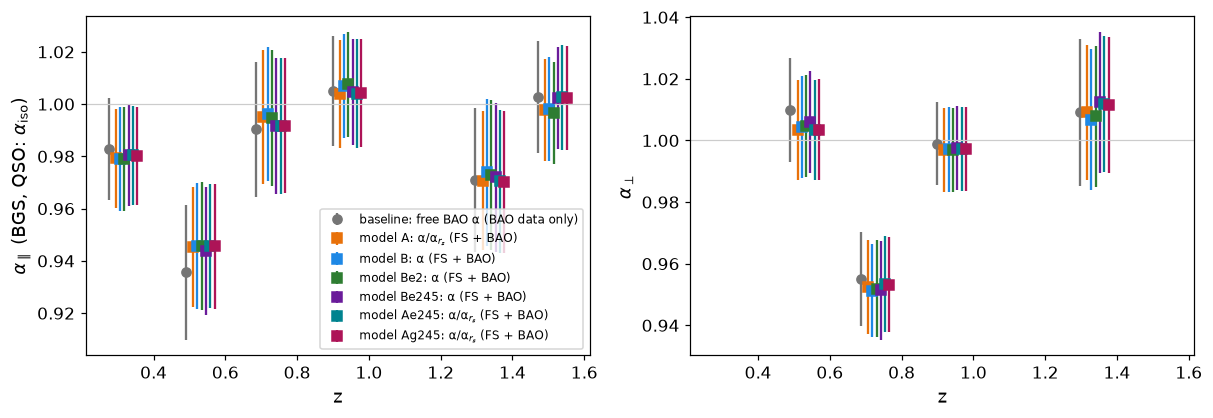

[  247.8s] model A: ln alpha_rs = +0.0384 +- 0.0282  (prior 0 +- 0.05): posterior/prior width 0.56; corr with the mean ln alpha +0.973


[  247.8s] model Be2: wiggle envelope e0 = +0.095 +- 0.166 (prior 0 +- 0.3)


[  247.8s] model Be2: wiggle envelope e1 = -0.100 +- 0.231 (prior 0 +- 0.3)


[  247.8s] model Be245: wiggle envelope e0 = +0.139 +- 0.174 (prior 0 +- 0.3)


[  247.8s] model Be245: wiggle envelope e1 = -0.186 +- 0.237 (prior 0 +- 0.3)


...

[  247.8s] model Ae245: wiggle envelope e0 = +0.114 +- 0.172 (prior 0 +- 0.3)


[  247.8s] model Ae245: wiggle envelope e1 = -0.122 +- 0.242 (prior 0 +- 0.3)


[  247.8s] model Ag245: ln alpha_rs = +0.0274 +- 0.0366  (prior 0 +- 0.05): posterior/prior width 0.73; corr with the mean ln alpha +0.984


[  247.8s] model Ag245: BAO amplitude A = +0.159 +- 0.159 (prior 0 +- 0.3)


[  247.8s] model Ag245: wiggle damping dSigma^2 [Mpc^2] = +6.963 +- 20.684 (prior 0 +- 25.0)


In [9]:
def bao_alphas(w, x):
    M = MW[w]; phi = x[:, M.n_eft:]; ln = lambda b: phi[:, M.pidx[b]]
    rs = phi[:, M.pidx['rs']] if M.rs_free else 0.0
    return np.exp(ln('apar') - rs), np.exp(ln('aper') - rs) * np.asarray(M.bao_dm_factor)
ALPH = {w: bao_alphas(w, CH[w]) for w in RUNS}
old = np.exp(CH['old'][:, M0.idx['bao']])
fig, axs = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for j, z in enumerate(M0.z):
    sl = M0.bao_slice[j]; iso = M0.bao_iso[j]
    for comp, ax in ((0, axs[0]), (1, axs[1])):
        if iso and comp == 1: continue
        o = old[:, sl][:, 0] if iso else old[:, sl][:, comp]
        ax.errorbar(z - 0.02, o.mean(), o.std(), fmt='o', color=C_OLD, label='baseline: free BAO α (BAO data only)' if j == 0 else None)
        for i, w in enumerate(RUNS):
            ap, ae = ALPH[w]; v = ap[:, j]**(1/3) * ae[:, j]**(2/3) if iso else (ap[:, j] if comp == 0 else ae[:, j])
            ax.errorbar(z + 0.012 * i, v.mean(), v.std(), fmt='s', color=COL[w], label=(f'model {w}: ' + (r'α/α$_{r_s}$' if MW[w].rs_free else 'α') + ' (FS + BAO)') if j == 0 else None)
            log(f"z={z:.3f} {'iso' if iso else ['par', 'per'][comp]}: baseline {o.mean():.4f}+-{o.std():.4f}  {w} {v.mean():.4f}+-{v.std():.4f} (width ratio {v.std()/o.std():.2f})")
axs[0].set_ylabel(r'$\alpha_\parallel$ (BGS, QSO: $\alpha_{\rm iso}$)'); axs[1].set_ylabel(r'$\alpha_\perp$')
for ax in axs: ax.set_xlabel('z'); ax.axhline(1, color='0.8', lw=0.8)
axs[0].legend(fontsize=8); savefig('alphas'); plt.close('all')
for w in RUNS:
    M = MW[w]; ph = CH[w][:, M.n_eft:]
    if M.rs_free:
        lnrs = ph[:, M.pidx['rs'][0]]
        log(f"model {w}: ln alpha_rs = {lnrs.mean():+.4f} +- {lnrs.std():.4f}  (prior 0 +- {M.prior['s_lnrs']}): posterior/prior width {lnrs.std() / M.prior['s_lnrs']:.2f}; "
            f"corr with the mean ln alpha {np.corrcoef(lnrs, ph[:, np.r_[M.pidx['apar'], M.pidx['aper']]].mean(1))[0, 1]:+.3f}")
    if M.n_env:
        e = ph[:, M.pidx['env']]
        for j, (nm, sg) in enumerate(zip(M.env_names(), M.env_sigmas())):
            log(f"model {w}: {nm} = {e[:, j].mean():+.3f} +- {e[:, j].std():.3f} (prior 0 +- {sg})")

The broadband: $\ln a(k)$ on the knots, with its 68% band (dashed for A). In B and Be2 it is the spectrum in
sound-horizon units relative to the fiducial. The direct ΛCDM posterior, mapped through B's least-squares
projection, is shown for comparison.

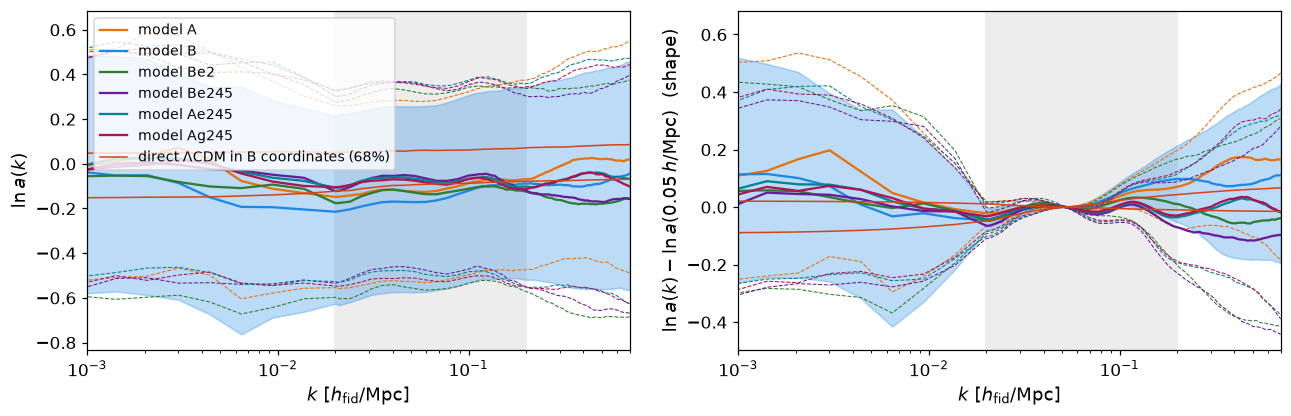

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4)); kh = MB.knots_h; ip = np.argmin(np.abs(kh - 0.05))
thd = np.load(S.files(s0)['chain_direct'])['x'].reshape(-1, M0.n_eft + 3)[:, M0.n_eft:]
fmap = MB.phi_ln_keys(COSMO_MODELS['lcdm3'])
lad = np.asarray(jax.vmap(lambda t: MB.lna_to_knots(fmap(t)[MB.pidx['lna']]))(jnp.array(thd[np.random.default_rng(1).choice(len(thd), 400, replace=False)])))
for ax, rel in zip(axs, (False, True)):
    for w in RUNS:
        M = MW[w]; sub = CH[w][np.random.default_rng(0).choice(len(CH[w]), 2000, replace=False), M.n_eft:]
        la = np.asarray(jax.vmap(M.lna_to_knots)(jnp.array(sub[:, M.pidx['lna']])))
        if rel: la = la - la[:, [ip]]
        q = np.percentile(la, [16, 50, 84], axis=0)
        ax.plot(kh, q[1], color=COL[w], label=f'model {w}')
        if w == 'B': ax.fill_between(kh, q[0], q[2], color=COL[w], alpha=0.3)
        else: ax.plot(kh, q[0], color=COL[w], lw=0.7, ls='--'); ax.plot(kh, q[2], color=COL[w], lw=0.7, ls='--')
    ld = lad - lad[:, [ip]] if rel else lad
    ax.plot(kh, np.percentile(ld, 16, 0), color=C_D, lw=1); ax.plot(kh, np.percentile(ld, 84, 0), color=C_D, lw=1, label='direct ΛCDM in B coordinates (68%)')
    ax.set_xscale('log'); ax.axvspan(0.02, 0.2, color='0.93', zorder=0); ax.set_xlim(1e-3, 0.7); ax.set_xlabel(r'$k\ [h_{\rm fid}/{\rm Mpc}]$')
axs[0].set_ylabel(r'$\ln a(k)$'); axs[1].set_ylabel(r'$\ln a(k)-\ln a(0.05\,h/{\rm Mpc})$  (shape)'); axs[0].legend(fontsize=9)
savefig('broadband'); plt.close('all')

## 6. The recovery tests

Each row is one model. The columns give the largest |shift| of any parameter of the MI → model projection, in units
of the reference σ, against the **true direct likelihood**. That is the engine's spectrum at the emulator's knots
with the corrected sound horizon (`wiggle_direct.py <model> exact`, `output/desi_fsbao/exact_*`), sampled with the
same NUTS settings, priors and boxes as the existing direct chains. Section 3b showed why the existing chains are not
a good enough reference. "repr." is the shift the representation alone causes: the reference chain reweighted by
$L_{\rm wiggle}/L_{\rm true}$ on 2000 draws. The baseline 106-parameter MI model, with the same 64k samples and the
same two density estimators (Gaussian, flow ensemble c5), is shown against the truth and against its own direct
chain, as in the meeting. The pass criterion of the existing tests is |shift| < 0.3σ with widths within 20%.

**The sound horizon.** `pybird.symbolic.rs_drag`, the $r_d$ of every CosmoPower direct model, has the $\omega_b$
exponent with the wrong sign: $d\ln r_d/d\ln\omega_b=+0.09$ where a numerical integral gives $-0.17$. That is 0.65% per
BBN σ of $\omega_b$, and it matters for lcdm5 and w0wa7, where $\omega_b$ is free. The true-likelihood references use
the corrected $r_d$; the baseline columns "own" keep the original.

In [11]:
def baseline_samples(cv, est):
    if cv in ('baseline', 'ede7'):
        f = os.path.join(S.OUT_ROOT, 'meeting', f'B0_flow_study_{est}.npz')
        return np.load(f)[f"{'lcdm3' if cv == 'baseline' else 'ede7'}_samples"] if os.path.exists(f) else None
    f = os.path.join(S.OUT_ROOT, cv, f'chain_projected_{est}.npz')
    return np.load(f)['x'].reshape(-1, len(COSMO_MODELS[S.resolve(cv)['cosmo_model']])) if os.path.exists(f) else None

from wiggle_direct import rdfix_files
def direct_file(cv, fixed=True):
    """The reference chain, as wiggle_recovery.reference: the true-likelihood chain (wiggle_direct.py exact), else the
    corrected-r_d one, else the original; fixed=False: always the original direct chain."""
    for kind in (('exact', 'exactrw', 'rdfix') if fixed else ()):
        f = rdfix_files(cv, kind)[1]['chain_direct']
        if os.path.exists(f): return f
    return S.files(S.resolve(cv))['chain_direct']

def direct_samples(cv, fixed=True):
    x = np.load(direct_file(cv, fixed))['x']; return x.reshape(-1, x.shape[-1])[:, M0.n_eft:]

def shifts(th_d, th):
    return (th.mean(0) - th_d.mean(0)) / th_d.std(0), th.std(0) / th_d.std(0)

REC = {(w, est): dict(np.load(os.path.join(OUT[w], f'recovery_{est}.npz'))) for w in REC_RUNS for est in ('gauss', 'c5')
       if os.path.exists(os.path.join(OUT[w], f'recovery_{est}.npz'))}
for cv in W.COSMO_VARIANTS: log(f"reference for {cv}: {direct_file(cv)}")
cols = [('baseline', 'gauss', 'own'), ('baseline', 'gauss', 'truth'), ('baseline', 'c5', 'truth')] + \
       [(w, e, 'truth') for w in REC_RUNS for e in ('gauss', 'c5', 'repr.')]
print(f"{'model':9s} | " + " ".join(f"{(w + ' ' + e + ('' if r == 'truth' else ' ' + r)):>15s}" for w, e, r in cols)); print('-' * (12 + 16 * len(cols)))
for cv in W.COSMO_VARIANTS:
    th_d, row = direct_samples(cv), []
    for w, est, ref in cols:
        if w == 'baseline':
            b = baseline_samples(cv, est); ref_th = direct_samples(cv, fixed=(ref == 'truth'))
            row.append(np.abs(shifts(ref_th, b)[0]).max() if b is not None else np.nan)
        else:
            r = REC.get((w, 'gauss' if est == 'repr.' else est))
            row.append(np.nan if r is None or f'{cv}_shift' not in r else np.abs(r[f'{cv}_shift_rep' if est == 'repr.' else f'{cv}_shift']).max())
    print(f"{cv:9s} | " + " ".join(f"{x:15.2f}" for x in row))

[  258.3s] reference for baseline: /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/output/desi_fsbao/exact_baseline/chain_direct.npz


[  258.3s] reference for lcdm5: /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/output/desi_fsbao/exact_lcdm5/chain_direct_lcdm5.npz


[  258.3s] reference for w0wa7: /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/output/desi_fsbao/exact_w0wa7/chain_direct_w0wa7.npz


[  258.3s] reference for ede7: /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/output/desi_fsbao/exact_ede7/chain_direct_ede7.npz


model     | baseline gauss own  baseline gauss     baseline c5         A gauss            A c5         A repr.         B gauss            B c5         B repr.       Be2 gauss          Be2 c5       Be2 repr.     Be245 gauss        Be245 c5     Be245 repr.      Be2F gauss         Be2F c5      Be2F repr.    Be245F gauss       Be245F c5    Be245F repr.    Ae245F gauss       Ae245F c5    Ae245F repr.    Ag245F gauss       Ag245F c5    Ag245F repr.
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
baseline  |            0.18            0.67            0.47            0.72            0.89            0.78 

lcdm5     |            0.71            1.36            0.78            1.18            1.15            1.29            1.09            0.85            1.04            0.54            0.47            0.47            0.43            0.39            0.24            0.52            0.40            0.25            0.24            0.15            0.08            0.29            0.14            0.14            0.25            0.26            0.10


w0wa7     |            0.98            1.52            0.88            1.78            1.92            1.61            2.01            1.97            1.63            0.74            0.69            0.54            0.61            0.41            0.39            0.68            0.67            0.42            0.32            0.34            0.34            0.71            0.12            0.11            0.66            0.20            0.14


ede7      |            0.30            0.85            0.97            0.53            0.68            0.75            0.43            0.59            0.64            0.42            0.39            0.34            0.23            0.22            0.22            0.50            0.41            0.27            0.23            0.18            0.16            0.14            0.21            0.15            0.19            0.11            0.14


In [12]:
for (w, est), r in REC.items():
    for cv in [c for c in W.COSMO_VARIANTS if f'{c}_names' in r]:
        log(f"[{w} {est}] {cv:9s} " + "  ".join(f"{n} {a:+.2f}σ ×{b:.2f}" for n, a, b in zip(list(r[f'{cv}_names']), r[f'{cv}_shift'], r[f'{cv}_ratio']))
            + "   | representation " + " ".join(f"{a:+.2f}" for a in r[f'{cv}_shift_rep']))

[  259.1s] [A gauss] baseline  omega_cdm +0.72σ ×0.97  logA -0.37σ ×0.91  h +0.43σ ×1.00   | representation +0.78 -0.28 +0.29


[  259.1s] [A gauss] lcdm5     omega_cdm +1.18σ ×1.34  omega_b +0.19σ ×1.01  n_s -0.91σ ×1.26  logA -0.76σ ×0.98  h +0.53σ ×1.04   | representation +1.29 +0.28 -0.94 -0.64 +0.53


[  259.1s] [A gauss] w0wa7     omega_cdm +1.78σ ×1.20  omega_b +0.16σ ×1.02  n_s -1.43σ ×1.02  logA -0.96σ ×0.88  h +1.24σ ×0.89  w0 -0.49σ ×0.83  wa +0.08σ ×0.89   | representation +1.61 +0.26 -1.47 -0.83 +0.38 +0.20 -0.40


[  259.1s] [A gauss] ede7      omega_cdm +0.53σ ×0.97  omega_b -0.17σ ×1.00  logA -0.10σ ×0.91  h +0.44σ ×1.00  fEDE +0.22σ ×0.93  log10z_c -0.10σ ×0.80  thetai_scf +0.12σ ×1.01   | representation +0.75 -0.26 -0.02 +0.64 +0.38 -0.15 +0.20


[  259.1s] [A c5] baseline  omega_cdm +0.89σ ×1.03  logA -0.34σ ×0.92  h +0.53σ ×1.04   | representation +0.78 -0.28 +0.29


...

[  259.1s] [Ag245F gauss] ede7      omega_cdm -0.06σ ×0.97  omega_b -0.03σ ×0.99  logA -0.19σ ×0.96  h -0.07σ ×0.97  fEDE -0.12σ ×0.94  log10z_c +0.09σ ×0.97  thetai_scf +0.03σ ×0.99   | representation -0.08 -0.04 -0.07 -0.11 -0.08 +0.14 +0.00


[  259.1s] [Ag245F c5] baseline  omega_cdm -0.18σ ×0.97  logA +0.18σ ×0.98  h -0.06σ ×1.03   | representation +0.02 -0.04 +0.01


[  259.1s] [Ag245F c5] lcdm5     omega_cdm -0.26σ ×0.98  omega_b +0.02σ ×0.99  n_s +0.18σ ×0.97  logA +0.26σ ×0.99  h -0.08σ ×1.02   | representation +0.10 +0.06 -0.08 -0.06 +0.05


[  259.1s] [Ag245F c5] w0wa7     omega_cdm -0.17σ ×1.03  omega_b +0.01σ ×1.01  n_s +0.20σ ×1.01  logA +0.17σ ×1.00  h +0.01σ ×1.05  w0 -0.08σ ×1.05  wa +0.10σ ×1.01   | representation +0.08 +0.03 -0.07 -0.05 -0.13 +0.14 -0.11


[  259.1s] [Ag245F c5] ede7      omega_cdm -0.09σ ×1.02  omega_b -0.00σ ×0.99  logA +0.11σ ×0.96  h -0.03σ ×1.01  fEDE -0.05σ ×0.98  log10z_c +0.03σ ×1.00  thetai_scf -0.01σ ×0.99   | representation -0.08 -0.04 -0.07 -0.11 -0.08 +0.14 +0.00


Triangles: the true-likelihood direct chain is filled. Four projections are drawn with the flow estimate (c5), the one
to use (section 7):
- the recommended model **Ag245F** (BAO-fit wiggle template);
- Ae245F, the same model with the $e_0$, $e_1$ envelope;
- the original proposal A;
- the baseline 106-parameter model (dashed grey).

The legend gives each curve's largest |shift| in units of the direct σ for the flow, with the Gaussian value in brackets.
The table above has every variant.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


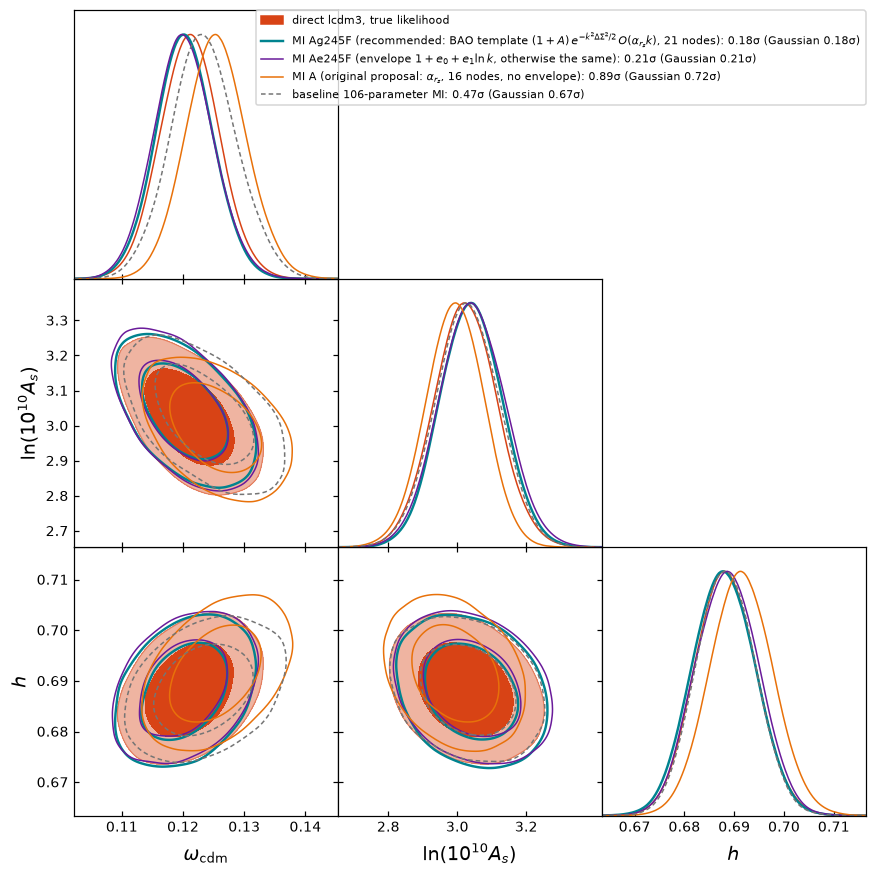

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


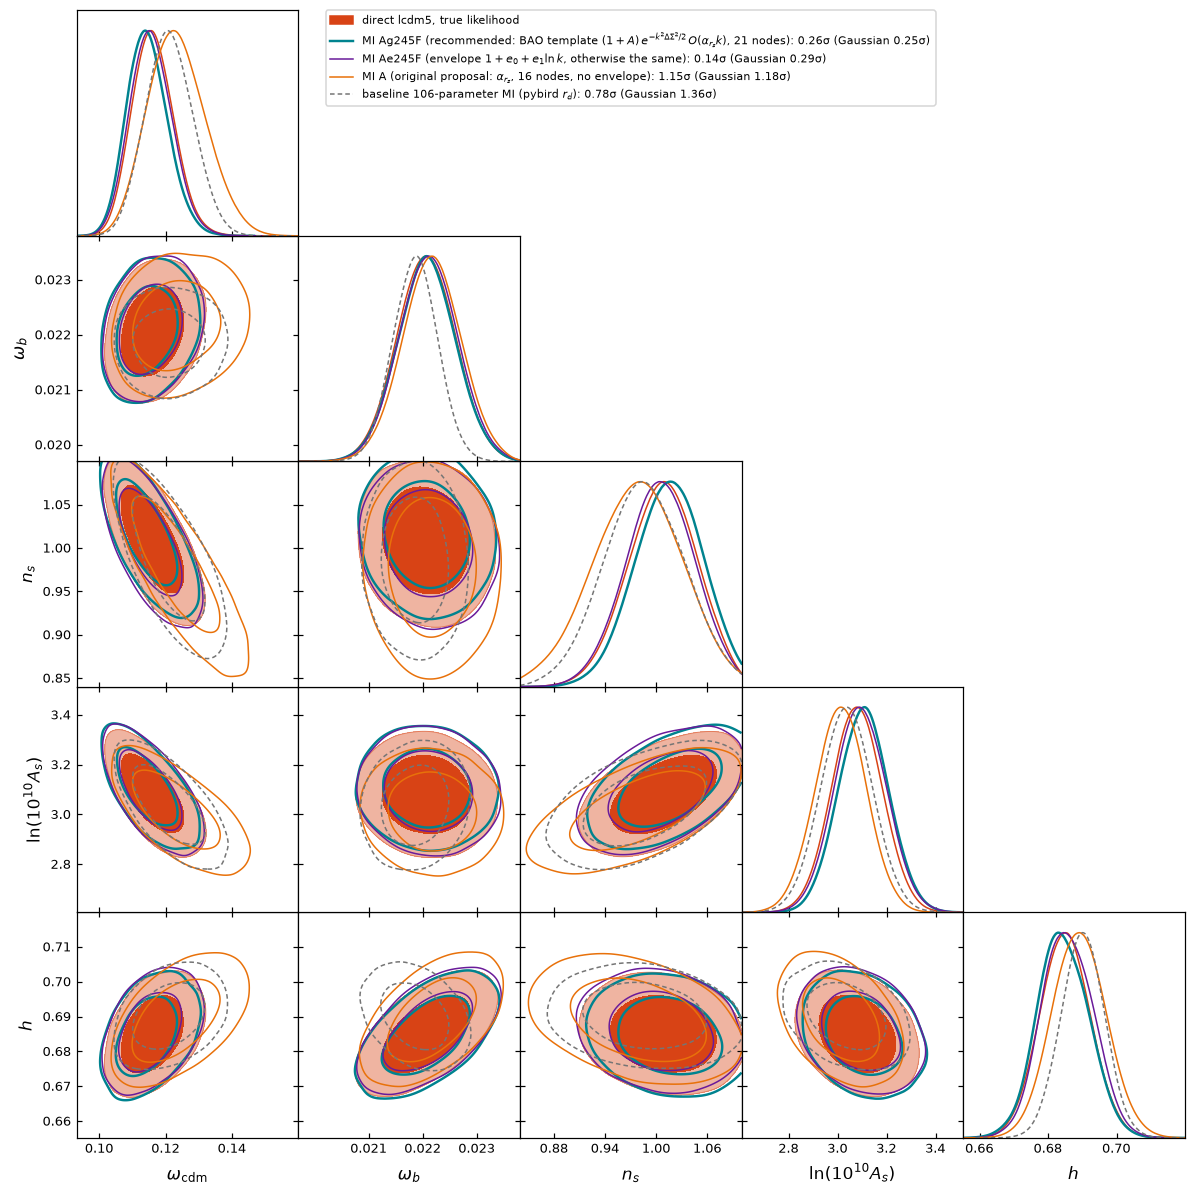

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


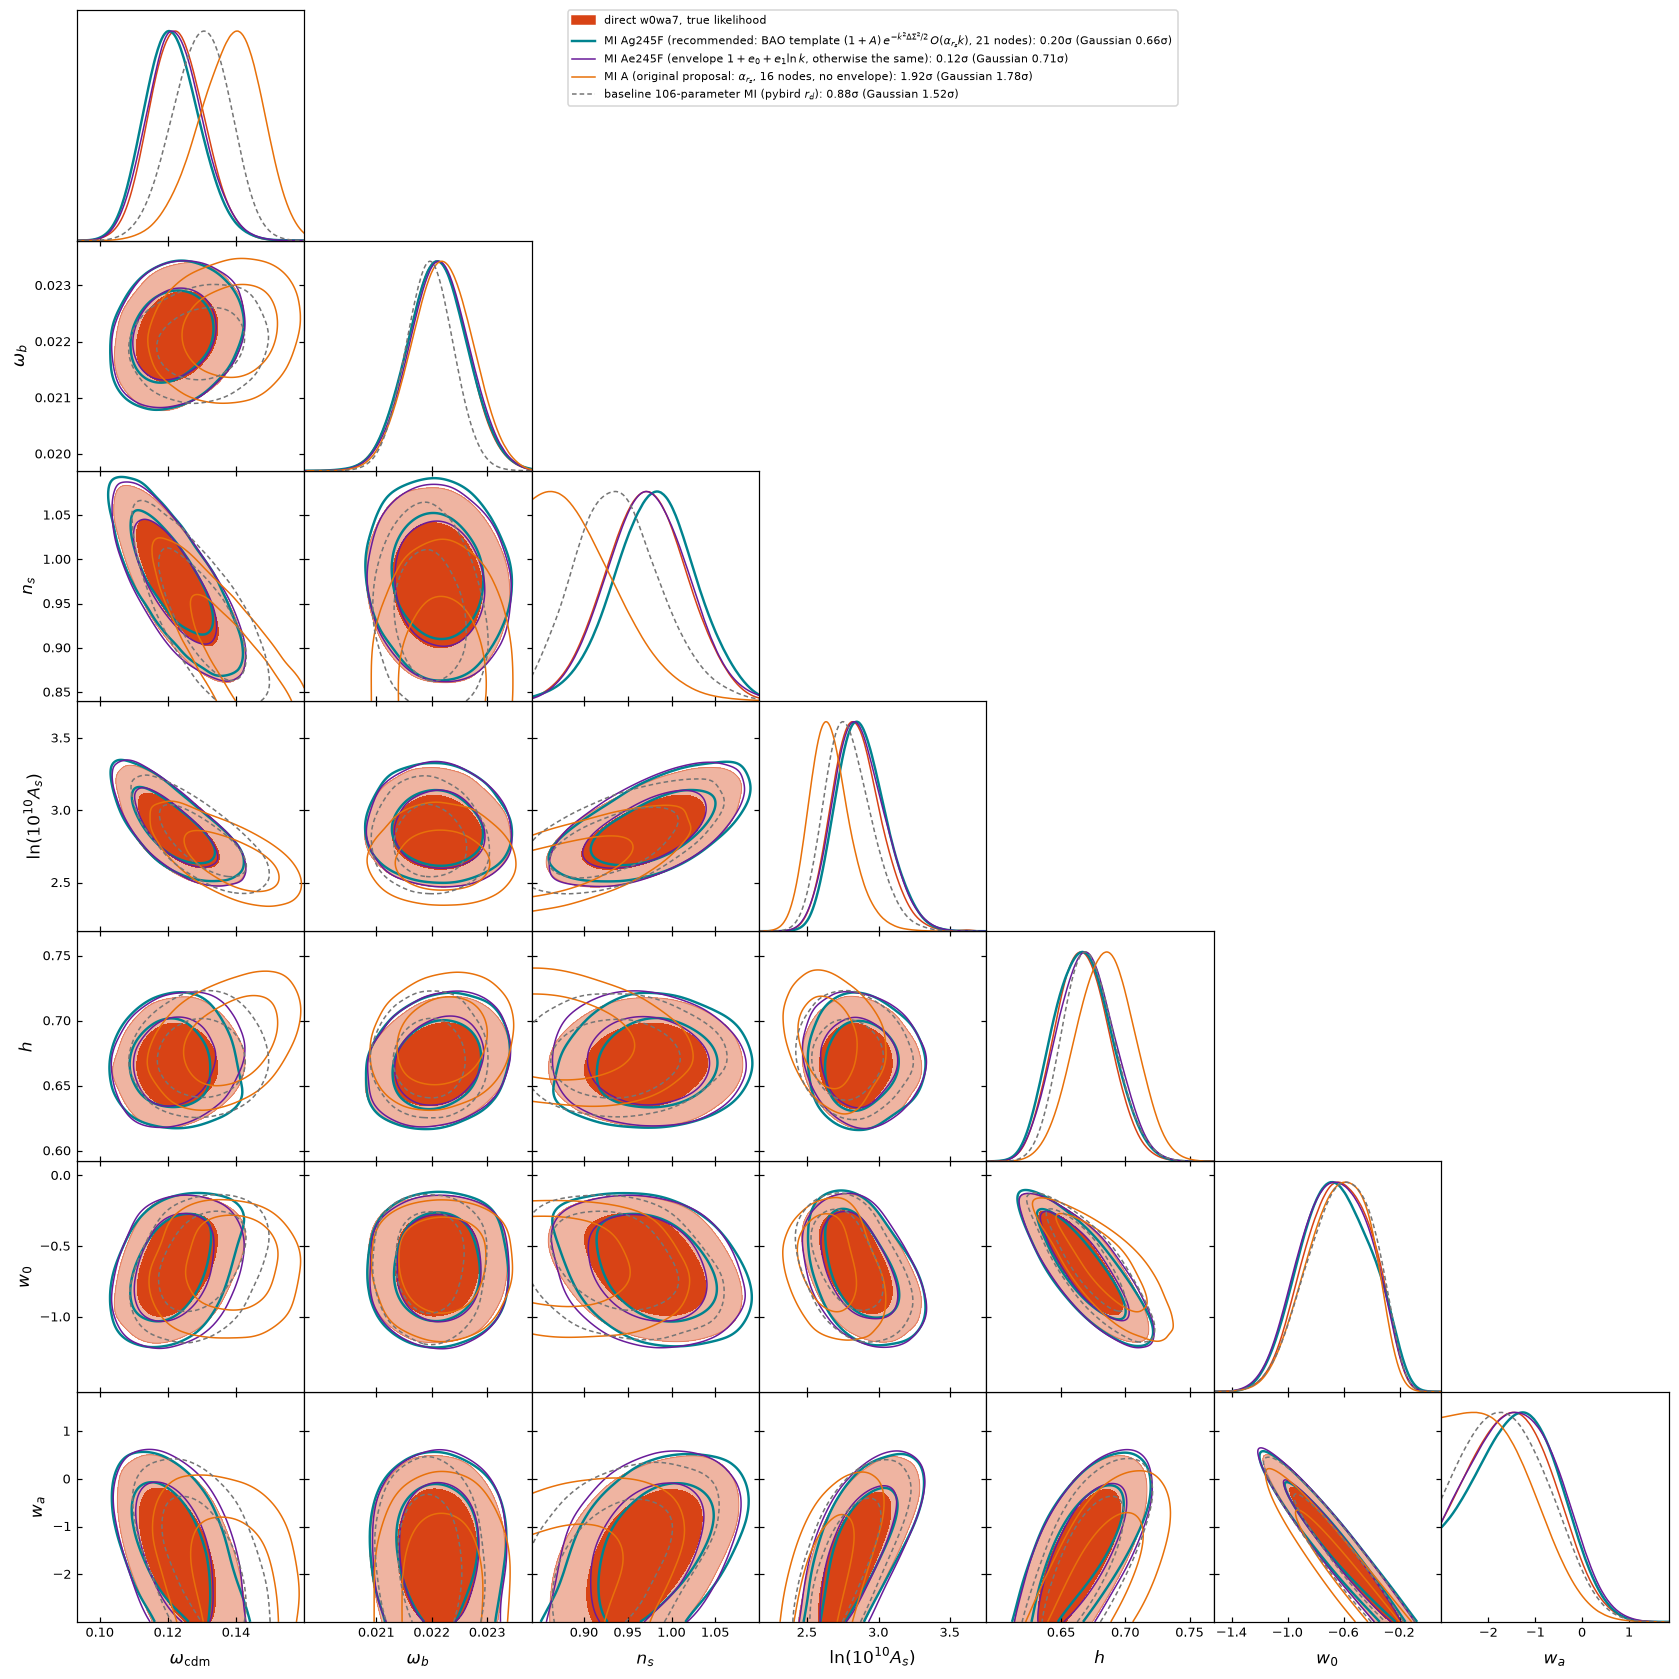

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


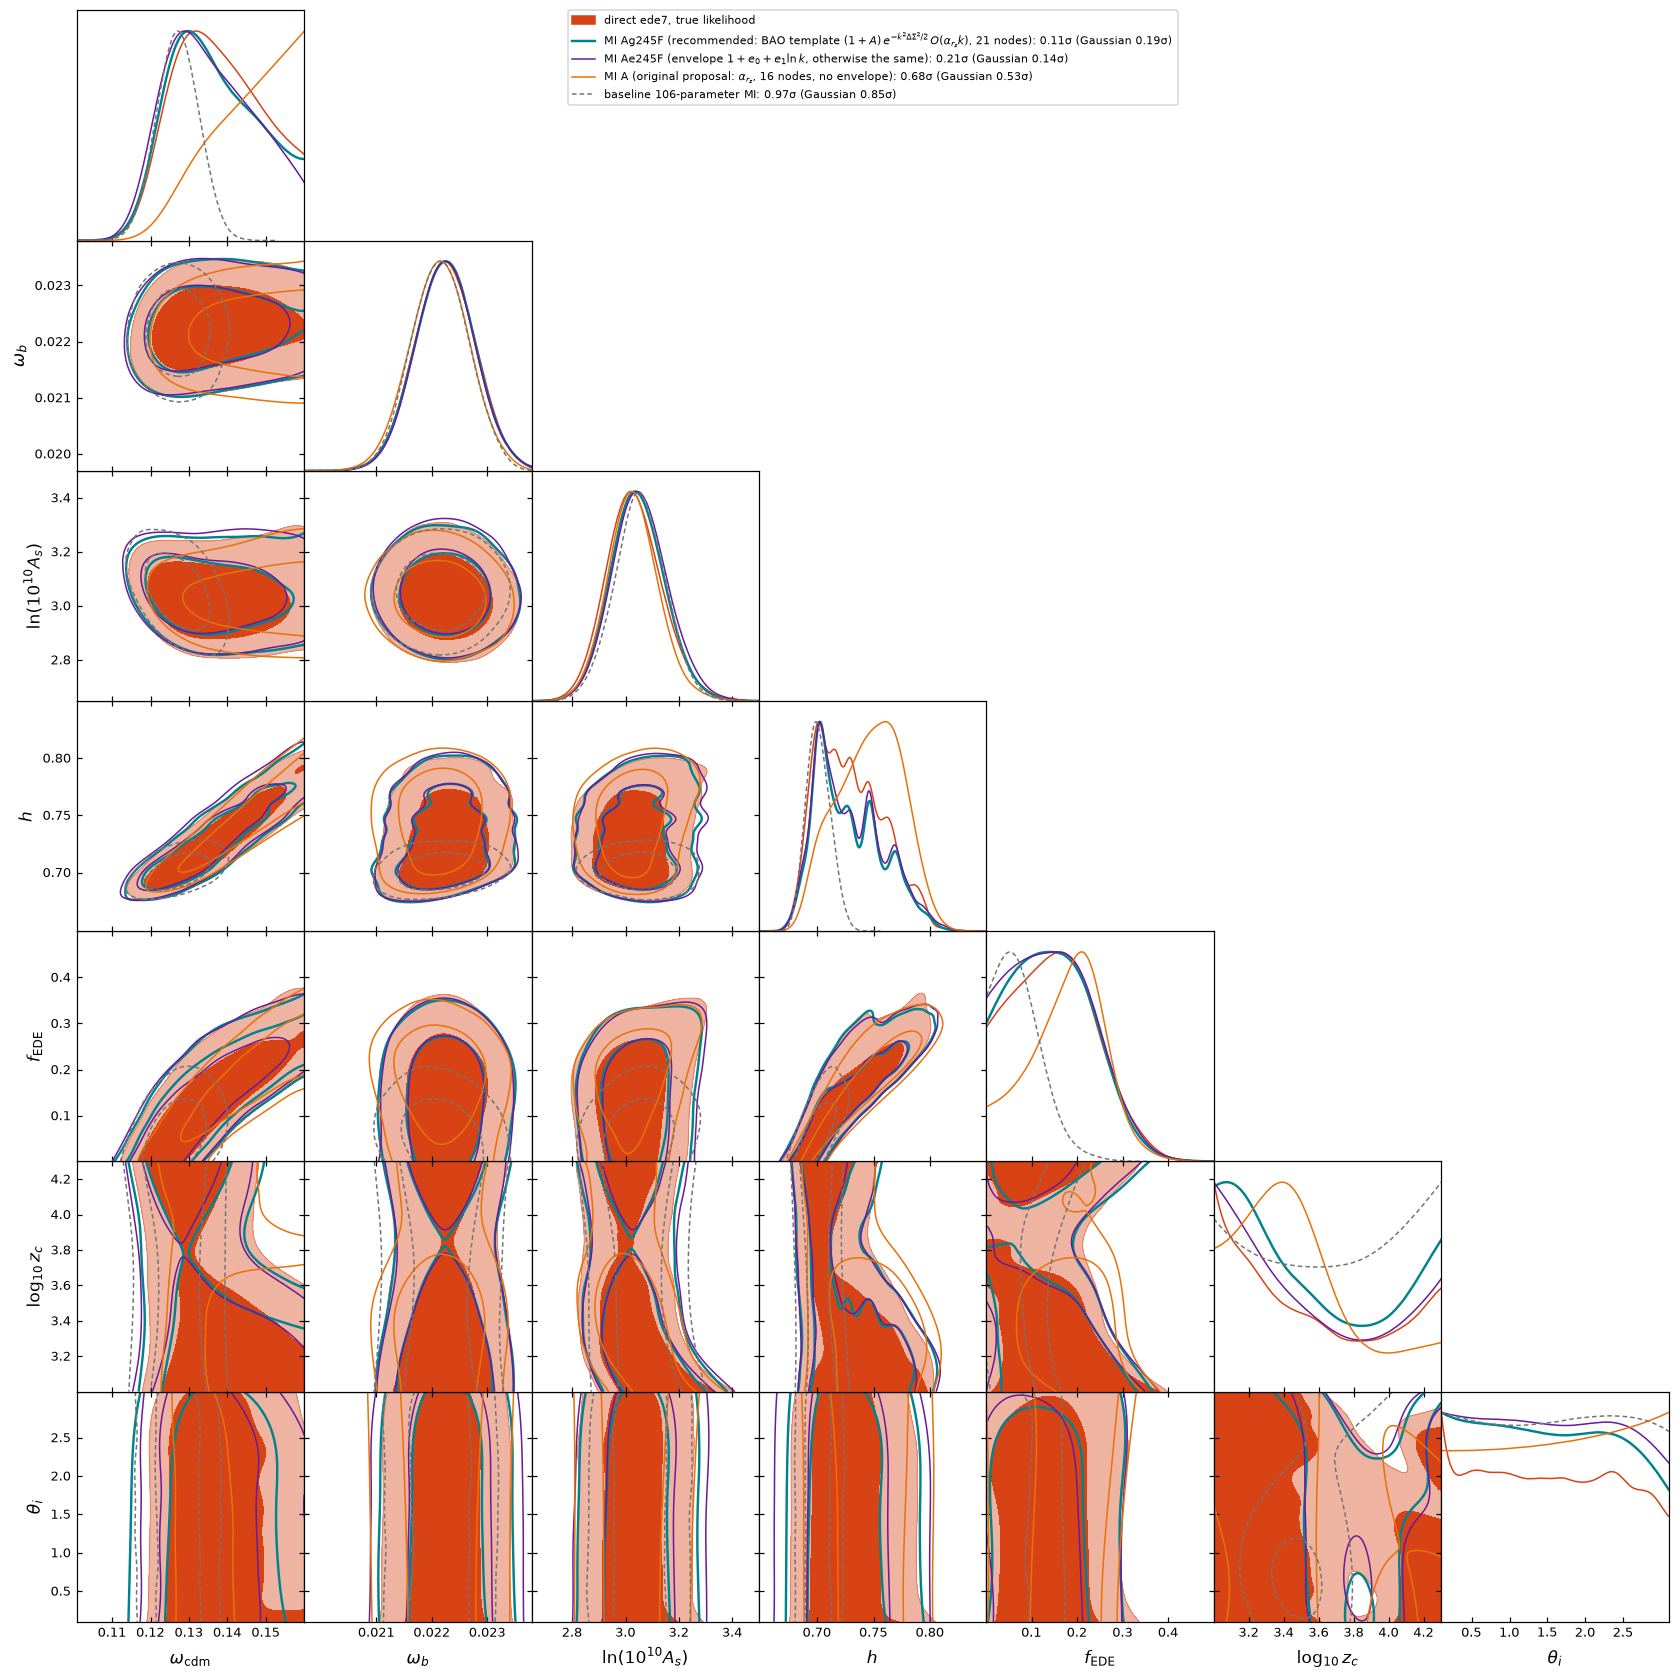

In [13]:
SHOW = [('Ag245F', '#00838F', r'recommended: BAO template $(1+A)\,e^{-k^2\Delta\Sigma^2/2}\,O(\alpha_{r_s}k)$, 21 nodes'),
        ('Ae245F', '#6A1B9A', r'envelope $1+e_0+e_1\ln k$, otherwise the same'), ('A', '#E8710A', r'original proposal: $\alpha_{r_s}$, 16 nodes, no envelope')]
for cv in W.COSMO_VARIANTS:
    sv = S.resolve(cv); model = sv['cosmo_model']; keys = COSMO_MODELS[model]; names = ['logA' if k == 'lnAs' else k for k in keys]
    box = {n: (EDE_BOX.get(k, COSMO_BOX[k]) if model == 'ede7' else COSMO_BOX[k]) for n, k in zip(names, keys)}
    mk = lambda th, lab: MCSamples(samples=th, names=names, labels=[COSMO_TEX[k] for k in keys], ranges=box, label=lab)
    th_d = direct_samples(cv)
    roots, cols_, labs, filled, ls, lws = [mk(th_d, 'direct')], [C_D], [f'direct {model}, true likelihood'], [True], ['-'], [1.0]
    for w, c, desc in SHOW:
        rg, rc = REC.get((w, 'gauss')), REC.get((w, 'c5'))
        if rc is None or f'{cv}_samples' not in rc: continue
        mx = f"{np.abs(rc[f'{cv}_shift']).max():.2f}σ" + (f" (Gaussian {np.abs(rg[f'{cv}_shift']).max():.2f}σ)" if rg is not None and f'{cv}_shift' in rg else '')
        roots.append(mk(rc[f'{cv}_samples'], w)); cols_.append(c); labs.append(f'MI {w} ({desc}): {mx}'); filled.append(False); ls.append('-'); lws.append(1.6 if w == 'Ag245F' else 1.0)
    b, bc = baseline_samples(cv, 'gauss'), baseline_samples(cv, 'c5')
    if bc is not None:
        mx = f"{np.abs(shifts(th_d, bc)[0]).max():.2f}σ" + (f" (Gaussian {np.abs(shifts(th_d, b)[0]).max():.2f}σ)" if b is not None else '')
        roots.append(mk(bc, 'old')); cols_.append(C_OLD); filled.append(False); ls.append('--'); lws.append(1.0)
        labs.append(f'baseline 106-parameter MI' + (' (pybird $r_d$)' if cv in ('lcdm5', 'w0wa7') else '') + f': {mx}')
    g = plots.get_subplot_plotter(subplot_size=2.2 if len(keys) > 4 else 2.7); g.settings.num_plot_contours = 2; g.settings.alpha_filled_add = 0.3
    g.settings.legend_fontsize = 10 if len(keys) > 4 else 9
    g.triangle_plot(roots, filled=filled, contour_colors=cols_, contour_ls=ls, contour_lws=lws, legend_labels=labs)
    g.export(os.path.join(FIG, f'recovery_{cv}.png')); g.export(os.path.join(FIG, f'recovery_{cv}.pdf')); plt.show(); plt.close('all')

## 7. Summary

1. **$\alpha_{r_s}$ is a near-gauge.** Scaling $\alpha_{r_s}$ and all twelve α's by 3% together, with the spline
   refitted, costs $\Delta\chi^2\le0.6$ at 16, 8 and 6 nodes. $\alpha_{r_s}$ alone costs 66. Even 6 nodes hold 96% of a
   broadband dilation, so fewer nodes do not pin it. Model B ($\alpha_{r_s}\equiv1$) is the same model without this
   direction. Its two α per redshift *are* the BAO α's, its template is $P(k\,r_d)/r_d^3$, and it needs no wiggle split.
2. **A rigid wiggle template needs a free amplitude and damping.** Without them (A, B), real spectra map into the
   model with posterior shifts of 0.6–2.2σ against the true likelihood: the BAO amplitude and damping follow
   $\omega_b/\omega_m$, which $\alpha_{r_s}$ cannot do.
   - The **BAO-fit form** $(1+A)\,e^{-k^2\Delta\Sigma^2/2}$ (Ag245F) and the log form $1+e_0+e_1\ln(k/k_*)$ (Ae245F) do
     equally well: map-only shifts 0.04–0.15σ against 0.09–0.17σ.
   - **The amplitude is needed.** Damping alone diverges. An amplitude alone ($e_0$) fails w0wa at 0.51σ with 21 nodes;
     only about 60 nodes absorb the damping, and those can also slide the wiggles.
   - The data barely constrain the two: $A=0.16\pm0.16$ and $\Delta\Sigma^2=7\pm21\,{\rm Mpc}^2$, against
     $\Lambda$CDM's $-0.02\pm0.07$ and $-1.5\pm4.4\,{\rm Mpc}^2$.
3. **Frame, nodes and map** (section 3c).
   - **Keep $\alpha_{r_s}$ explicit.** With $\alpha_{r_s}\equiv1$ the dimensionful EFT priors act in $r_d$ units, which
     costs 0.4σ in $h$ and $w_0$ for w0wa. With $\alpha_{r_s}$ explicit they act in $h$/Mpc, as in a direct fit, and
     the cost is 0.09σ.
   - **Nodes and map.** 21 nodes (spacing 0.45, too coarse to slide a wiggle) with the data-weighted map
     ($W=J^TC^{-1}J$ on the knots) bring every model to ≤0.15σ, map only.
4. **Found on the way (they affect the existing direct chains, not the MI chains):**
   `pybird.symbolic.rs_drag` has the $\omega_b$ exponent with the wrong sign (0.65% in $r_d$ per BBN σ).
   `symbolic.comoving_distance` starts at $z=10^{-3}$ (BAO $D_M$ low by 0.37% at $z=0.295$).
   The 60-node composition of the existing direct likelihood shifts ω_cdm by 0.5–0.9σ against the true likelihood.
   True-likelihood chains (`exact_*`) against the existing direct chains: ΛCDM ω_cdm 0.1235 → 0.1211 (−0.50σ), h unchanged;
   lcdm5 h 0.6915 → 0.6850 ± 0.0074 (−1.0σ) and ω_b back on its BBN prior (0.02163 ± 0.00037 → 0.02206 ± 0.00054). The
   meeting's open "ω_b offset" was the $r_d$ sign. w0wa7: ω_cdm −0.56σ, ω_b +0.96σ, w0 and wa < 0.2σ.
5. **The two shared α's per redshift are as tight as post-reconstruction BAO alone** (width ratios 0.93–1.02 against
   the baseline's free BAO α's). Tying the full-shape AP to them gives one consistent set of distances at no cost.
6. **Recovery tests** (section 6; reference: the sampled true-likelihood chain of every model).
   - **The recommended configuration, Ag245F,** passes with the flow estimator. In max |shift|: 0.18σ (ΛCDM),
     0.26σ (ΛCDM + ω_b, n_s), 0.20σ (w0wa) and 0.11σ (EDE), widths within 5%. Its full specification is in
     `WIGGLE_SETUP.md` (59 sampled parameters).
   - **Use the flows.** The Gaussian estimate fails w0wa (0.66σ), because the $\alpha_{r_s}$ near-symmetry makes the MI
     posterior non-Gaussian.
   - Ae245F gives 0.21, 0.14, 0.12 and 0.21σ.
   - The 106-parameter baseline, against the same references: 0.67 / 0.47σ (ΛCDM), 1.36 / 0.78σ (lcdm5), 1.52 / 0.88σ
     (w0wa7) and 0.85 / 0.97σ (EDE), Gaussian / flow. Its old passes were agreement with its own 60-node composition.
   - The original proposal (A: $\alpha_{r_s}$, no envelope) misses by 0.7–1.9σ.
   - $A$ and $\Delta\Sigma^2$ are predicted by the cosmology in the projection, not sampled. Marginalizing them widens
     ω_cdm and n_s by about 25% (lcdm5) and biases EDE by 0.4–0.5σ.
7. **Model A.** $\ln\alpha_{r_s}=+0.038\pm0.028$ against its 0.05 prior, and it moves with the mean ln α
   (correlation 0.97): it follows the near-symmetry. A's α/α_rs and B's α agree within 0.003 (≤ 0.15σ) at every redshift.

The per-model, per-estimator lines below are the record (reference file named on each line).

In [14]:
rows = []
for cv in W.COSMO_VARIANTS:
    kind = direct_file(cv).split('/')[-2]
    for w in REC_RUNS:
        for est in ('gauss', 'c5'):
            r = REC.get((w, est))
            if r is None or f'{cv}_shift' not in r: continue
            sh, ra, rep = r[f'{cv}_shift'], r[f'{cv}_ratio'], r[f'{cv}_shift_rep']
            ok = (np.abs(sh) < 0.3).all() and (np.abs(ra - 1) < 0.2).all()
            rows.append(f"{cv:9s} {w:4s} {est:6s} max|shift| {np.abs(sh).max():.2f}σ (representation {np.abs(rep).max():.2f}σ), "
                        f"widths [{ra.min():.2f}, {ra.max():.2f}]  {'PASS' if ok else 'FAIL'}   reference {kind}")
print('\n'.join(rows) if rows else 'no recovery results yet')

baseline  A    gauss  max|shift| 0.72σ (representation 0.78σ), widths [0.91, 1.00]  FAIL   reference exact_baseline
baseline  A    c5     max|shift| 0.89σ (representation 0.78σ), widths [0.92, 1.04]  FAIL   reference exact_baseline
baseline  B    gauss  max|shift| 0.71σ (representation 0.70σ), widths [0.93, 1.04]  FAIL   reference exact_baseline
baseline  B    c5     max|shift| 0.68σ (representation 0.70σ), widths [0.99, 1.09]  FAIL   reference exact_baseline
baseline  Be2  gauss  max|shift| 0.42σ (representation 0.30σ), widths [0.99, 1.08]  FAIL   reference exact_baseline
baseline  Be2  c5     max|shift| 0.48σ (representation 0.30σ), widths [0.99, 1.09]  FAIL   reference exact_baseline
baseline  Be245 gauss  max|shift| 0.34σ (representation 0.15σ), widths [0.98, 1.04]  FAIL   reference exact_baseline
baseline  Be245 c5     max|shift| 0.26σ (representation 0.15σ), widths [0.96, 1.05]  PASS   reference exact_baseline
baseline  Be2F gauss  max|shift| 0.41σ (representation 0.17σ), widths 